In [1]:
# Import packages and modules
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow_decision_forests as tfdf

from sklearn.model_selection import train_test_split

2026-08-10 17:10:53.050045: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-08-10 17:10:53.460895: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-08-10 17:10:58.061734: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
# Check the version of TensorFlow Decision Forests
print("Found TensorFlow Decision Forests v" + tfdf.__version__)

Found TensorFlow Decision Forests v1.9.1


In [3]:
datasetPath = 'dataset/firstorder/kernel5-radius5/dataset.csv'

In [4]:
# Parameters
datasetPath = "dataset/glcm/kernel4-radius4/dataset.1p.csv"


In [5]:
# train/validation/test = 70/10/20
dataset = pd.read_csv(datasetPath)

train_data, temp_data = train_test_split(dataset, test_size=0.3, random_state=42)
validation_data, test_data = train_test_split(temp_data, test_size=2/3, random_state=42)

In [6]:
from sklearn.utils.class_weight import compute_class_weight

# tinh class weight tren tap train
classes = np.array([0, 1])
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_data["label"])
class_weight = {0: weights[0], 1: weights[1]}

# gan sample_weight cho tung dong
train_data["sample_weight"] = train_data["label"].map(class_weight)
validation_data["sample_weight"] = validation_data["label"].map(class_weight)
test_data["sample_weight"] = test_data["label"].map(class_weight)

# Convert the dataset into a TensorFlow dataset.
train_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    train_data, label="label", weight="sample_weight"
)         
val_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    validation_data, label="label", weight="sample_weight"
)
test_ds = tfdf.keras.pd_dataframe_to_tf_dataset(
    test_data, label="label", weight="sample_weight"
)

2026-08-10 17:11:10.969523: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:984] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-08-10 17:11:10.970806: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [7]:
import keras

In [8]:
%%time

# Train a Gradient Boosted Trees model.
model = tfdf.keras.GradientBoostedTreesModel()

# Add evaluation metrics
model.compile(
    metrics=["accuracy"]
)
model.fit(x=train_ds)

# # Train a Gradient Boosted Trees model.
# model = tfdf.keras.GradientBoostedTreesModel(num_trees=1500)
# model.fit(train_ds)

Use /tmp/tmp7hymfb7e as temporary training directory


Reading training dataset...


[WARNING 26-08-10 17:11:11.9187 UTC gradient_boosted_trees.cc:1840] "goss_alpha" set but "sampling_method" not equal to "GOSS".
[WARNING 26-08-10 17:11:11.9190 UTC gradient_boosted_trees.cc:1851] "goss_beta" set but "sampling_method" not equal to "GOSS".
[WARNING 26-08-10 17:11:11.9190 UTC gradient_boosted_trees.cc:1865] "selective_gradient_boosting_ratio" set but "sampling_method" not equal to "SELGB".


Training dataset read in 0:00:03.700493. Found 1542 examples.


Training model...


Model trained in 0:00:01.905684


Compiling model...


[INFO 26-08-10 17:11:17.5407 UTC kernel.cc:1233] Loading model from path /tmp/tmp7hymfb7e/model/ with prefix dc09c1d246854842
[INFO 26-08-10 17:11:17.5503 UTC quick_scorer_extended.cc:911] The binary was compiled without AVX2 support, but your CPU supports it. Enable it for faster model inference.
[INFO 26-08-10 17:11:17.5510 UTC abstract_model.cc:1362] Engine "GradientBoostedTreesQuickScorerExtended" built
[INFO 26-08-10 17:11:17.5510 UTC kernel.cc:1061] Use fast generic engine


Model compiled.


CPU times: user 9.05 s, sys: 2.6 s, total: 11.7 s
Wall time: 8.75 s


In [9]:
# Evaluate the model
evaluate = model.evaluate(val_ds, return_dict=True)
print()

for name, value in evaluate.items():
    print(f"{name}: {value:.4f}")

1/1 [==============================] - ETA: 0s - loss: 0.0000e+00 - accuracy: 1.0000

1/1 [==============================] - 3s 3s/step - loss: 0.0000e+00 - accuracy: 1.0000



loss: 0.0000
accuracy: 1.0000


In [10]:
# Model Summary
model.summary()

Model: "gradient_boosted_trees_model"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


Total params: 1 (1.00 Byte)


Trainable params: 0 (0.00 Byte)


Non-trainable params: 1 (1.00 Byte)


_________________________________________________________________


Type: "GRADIENT_BOOSTED_TREES"
Task: CLASSIFICATION
Label: "__LABEL"

Input Features (42):
	10Percentile
	90Percentile
	Autocorrelation
	ClusterProminence
	ClusterShade
	ClusterTendency
	Contrast
	Correlation
	DifferenceAverage
	DifferenceEntropy
	DifferenceVariance
	Energy
	Entropy
	Id
	Idm
	Idmn
	Idn
	Imc1
	Imc2
	InterquartileRange
	InverseVariance
	JointAverage
	JointEnergy
	JointEntropy
	Kurtosis
	MCC
	Maximum
	MaximumProbability
	Mean
	MeanAbsoluteDeviation
	Median
	Minimum
	Range
	RobustMeanAbsoluteDeviation
	RootMeanSquared
	Skewness
	SumAverage
	SumEntropy
	SumSquares
	TotalEnergy
	Uniformity
	Variance

Trained with weights

Variable Importance: INV_MEAN_MIN_DEPTH:
    1.                        "Idmn"  0.272634 ################
    2.                    "Contrast"  0.264761 ##############
    3.                 "JointEnergy"  0.256495 ############
    4.                      "Energy"  0.225014 ######
    5.                 "TotalEnergy"  0.223007 #####
    6.             "RootM

In [11]:
# Model features
model.make_inspector().features()

["10Percentile" (1; #0),
 "90Percentile" (1; #1),
 "Autocorrelation" (1; #2),
 "ClusterProminence" (1; #3),
 "ClusterShade" (1; #4),
 "ClusterTendency" (1; #5),
 "Contrast" (1; #6),
 "Correlation" (1; #7),
 "DifferenceAverage" (1; #8),
 "DifferenceEntropy" (1; #9),
 "DifferenceVariance" (1; #10),
 "Energy" (1; #11),
 "Entropy" (1; #12),
 "Id" (1; #13),
 "Idm" (1; #14),
 "Idmn" (1; #15),
 "Idn" (1; #16),
 "Imc1" (1; #17),
 "Imc2" (1; #18),
 "InterquartileRange" (1; #19),
 "InverseVariance" (1; #20),
 "JointAverage" (1; #21),
 "JointEnergy" (1; #22),
 "JointEntropy" (1; #23),
 "Kurtosis" (1; #24),
 "MCC" (1; #25),
 "Maximum" (1; #26),
 "MaximumProbability" (1; #27),
 "Mean" (1; #28),
 "MeanAbsoluteDeviation" (1; #29),
 "Median" (1; #30),
 "Minimum" (1; #31),
 "Range" (1; #32),
 "RobustMeanAbsoluteDeviation" (1; #33),
 "RootMeanSquared" (1; #34),
 "Skewness" (1; #35),
 "SumAverage" (1; #36),
 "SumEntropy" (1; #37),
 "SumSquares" (1; #38),
 "TotalEnergy" (1; #39),
 "Uniformity" (1; #40),
 

In [12]:
# Feature importance
model.make_inspector().variable_importances()

{'INV_MEAN_MIN_DEPTH': [("Idmn" (1; #15), 0.27263376204928463),
  ("Contrast" (1; #6), 0.2647607626330927),
  ("JointEnergy" (1; #22), 0.25649518394907284),
  ("Energy" (1; #11), 0.2250138689649987),
  ("TotalEnergy" (1; #39), 0.22300728959639454),
  ("RootMeanSquared" (1; #34), 0.22141013742048296),
  ("SumAverage" (1; #36), 0.2149522406565667),
  ("Maximum" (1; #26), 0.2142726552597758),
  ("JointAverage" (1; #21), 0.21396217911193352),
  ("Idn" (1; #16), 0.21302618444171253),
  ("90Percentile" (1; #1), 0.20979238852622673),
  ("MaximumProbability" (1; #27), 0.2069048109868975),
  ("Idm" (1; #14), 0.20071606485433904),
  ("Variance" (1; #41), 0.19994849733552453),
  ("Autocorrelation" (1; #2), 0.19927935547309583),
  ("Mean" (1; #28), 0.19837686733624463),
  ("DifferenceEntropy" (1; #9), 0.19830747119130226),
  ("Id" (1; #13), 0.1982445360955497),
  ("Kurtosis" (1; #24), 0.19818958356459115),
  ("Imc1" (1; #17), 0.1976598007408874),
  ("Imc2" (1; #18), 0.1972193430914749),
  ("Median

In [13]:
# Model self evaluation
model.make_inspector().evaluation()

Evaluation(num_examples=None, accuracy=1.0, loss=1.2783319789377856e-06, rmse=None, ndcg=None, aucs=None, auuc=None, qini=None)

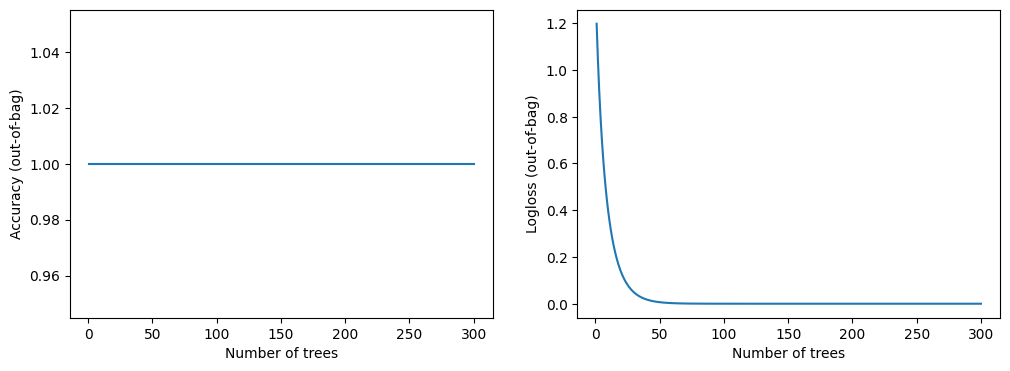

In [14]:
logs = model.make_inspector().training_logs()

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot([log.num_trees for log in logs], [log.evaluation.accuracy for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Accuracy (out-of-bag)")
plt.subplot(1, 2, 2)
plt.plot([log.num_trees for log in logs], [log.evaluation.loss for log in logs])
plt.xlabel("Number of trees")
plt.ylabel("Logloss (out-of-bag)")
plt.show()

Calculate the score of our hold-out validation dataset

In [15]:
predictions = model.predict(val_ds)
y_true      = validation_data["label"]

from sklearn.metrics import roc_auc_score
ROC_AUC = roc_auc_score(y_true, predictions)
print("The ROC AUC score is %.5f" % ROC_AUC )

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 75ms/step


The ROC AUC score is 1.00000


In [16]:
# Compute binary classification metrics with sklearn
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    log_loss,
    brier_score_loss,
)

# Get predictions (probabilities or class labels)
preds = model.predict(test_ds)
# If model outputs probabilities, convert to labels by threshold 0.5
if preds.ndim == 2:
    # For TFDF classification, preds may be class probabilities with shape (N, 2)
    if preds.shape[1] == 2:
        pos_probs = preds[:, 1]
    else:
        # If single-probability column (positive class)
        pos_probs = preds[:, -1]
    y_pred = (pos_probs >= 0.5).astype(int)
else:
    # Already class labels
    y_pred = preds.astype(int)
    pos_probs = None

# Ground truth labels (must be 0/1 integers)
y_true = test_data["label"].astype(int).to_numpy()

# Core metrics
metrics = {}
metrics["accuracy"] = accuracy_score(y_true, y_pred)
metrics["precision"] = precision_score(y_true, y_pred, zero_division=0)
metrics["recall"] = recall_score(y_true, y_pred, zero_division=0)
metrics["f1"] = f1_score(y_true, y_pred, zero_division=0)
metrics["mcc"] = matthews_corrcoef(y_true, y_pred)

# Probabilistic metrics (only if we have probabilities)
if pos_probs is not None:
    metrics["roc_auc"] = roc_auc_score(y_true, pos_probs)
    metrics["pr_auc"] = average_precision_score(y_true, pos_probs)
    metrics["log_loss"] = log_loss(y_true, pos_probs, labels=[0,1])
    metrics["brier_score"] = brier_score_loss(y_true, pos_probs)

# Confusion matrix and detailed report
cm = confusion_matrix(y_true, y_pred, labels=[0,1])
report = classification_report(y_true, y_pred, digits=4)

print("Sklearn binary metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}")
print("\nConfusion matrix:\n", cm)
print("\nClassification report:\n", report)

1/1 [==============================] - ETA: 0s

1/1 [==============================] - 0s 79ms/step


Sklearn binary metrics:
accuracy: 1.0000
precision: 1.0000
recall: 1.0000
f1: 1.0000
mcc: 1.0000
roc_auc: 1.0000
pr_auc: 1.0000
log_loss: 0.0000
brier_score: 0.0000

Confusion matrix:
 [[322   0]
 [  0 120]]

Classification report:
               precision    recall  f1-score   support

           0     1.0000    1.0000    1.0000       322
           1     1.0000    1.0000    1.0000       120

    accuracy                         1.0000       442
   macro avg     1.0000    1.0000    1.0000       442
weighted avg     1.0000    1.0000    1.0000       442

